In [1]:
# Core optimization library and plotting
import pyomo.environ as pyo
import matplotlib.pyplot as plt
# ripopt: a Rust reimplementation of IPOPT, packaged as `pyomo-ripopt`.
# Importing the package registers it with Pyomo's SolverFactory, so the
# `pyo.SolverFactory('ripopt')` call later resolves to the bundled binary.
import pyomo_ripopt  # noqa: F401

Sets

$\mathcal{I} = \{1, 2, 3, 4\}$ tanks \
$\mathcal{K} = \{1, 2\}$ pumps

Parameters

$A_i$ tank cross-section area (cm²) \
$a_i$ tank outlet area (cm²) \
$x_i^{ss}$ steady-state level (cm) \
$u_k^{ss}$ steady-state pump flow (ml/s) \
$\gamma_k$ pump-$k$ flow-split ratio \
$x_i^L, x_i^U$ per-tank level bounds (cm) \
$T$ horizon (s), $\rho$ control-penalty weight, $g = 981$ cm/s²

Variables

$x_i(t)$ level in tank $i$ (cm) \
$u_k(t)$ pump-$k$ flow rate (ml/s) \
$z_i(t) = x_i(t) - x_i^{ss}$ level deviation \
$v_k(t) = u_k(t) - u_k^{ss}$ flow deviation

Objective

\begin{gather}
 \min_{x(\cdot),\, u(\cdot)} \int_0^T \left( \sum_{i \in \mathcal{I}} z_i(t)^2 + \rho \sum_{k \in \mathcal{K}} v_k(t)^2 \right) dt
\end{gather}

Subject to (mass balance with flow split through pump valves):

\begin{align}
 \dot{x}_1 &= -\tfrac{a_1}{A_1}\sqrt{2 g x_1} + \tfrac{a_3}{A_1}\sqrt{2 g x_3} + \tfrac{\gamma_1}{A_1} u_1 \\
 \dot{x}_2 &= -\tfrac{a_2}{A_2}\sqrt{2 g x_2} + \tfrac{a_4}{A_2}\sqrt{2 g x_4} + \tfrac{\gamma_2}{A_2} u_2 \\
 \dot{x}_3 &= -\tfrac{a_3}{A_3}\sqrt{2 g x_3} + \tfrac{1 - \gamma_2}{A_3} u_2 \\
 \dot{x}_4 &= -\tfrac{a_4}{A_4}\sqrt{2 g x_4} + \tfrac{1 - \gamma_1}{A_4} u_1
\end{align}

with initial condition $x_i(0) = x_i^0$ (from the app sidebar), pump bounds $0 \le u_k(t) \le 60$ ml/s, and level bounds $x_i^L \le x_i(t) \le x_i^U$.

Solved by simultaneous direct transcription with orthogonal collocation on finite elements (Radau-IIA, 3 collocation points per element). The resulting NLP is handed to rIPOPT.

In [2]:
#Define the model
m = pyo.ConcreteModel()


# ── Discretisation ─────────────────────────────────────────────────────────────
# The optimal control problem is solved via direct collocation (Radau IIA, 3-point).
# The time horizon [0, N*h] = [0, 150 s] is divided into N finite elements,
# each of length h = 10 s, with ncp = 3 internal collocation points per element.

#sets

N = 15  # Number of finite elements
ncp = 3 # number of collocation points per element (Radau IIA, order 3)
m.i = pyo.Set(initialize=pyo.RangeSet(0,N-1)) # Finite element indices (0-indexed)
m.ii = pyo.Set(initialize=pyo.RangeSet(1,N)) # Finite element indices (1-indexed, for continuity constraints)
m.iii = pyo.Set(initialize=pyo.RangeSet(0,N)) # State breakpoint indices (element start/end points, N+1 total)
m.c = pyo.Set(initialize=pyo.RangeSet(1,ncp)) # Set of internal collocation points
m.t = pyo.Set(initialize=pyo.RangeSet(1,4)) # Set of tanks

# ── Variables ──────────────────────────────────────────────────────────────────
# All state variables are expressed as DEVIATIONS from steady state (z = x - x_ss).
# This formulation simplifies the objective and boundary conditions.

#variables

# z_k0[i]: state of tank k at the START of finite element i (breakpoint values, N+1 total)
m.z10 = pyo.Var(pyo.RangeSet(0,N))
m.z20 = pyo.Var(pyo.RangeSet(0,N))
m.z30 = pyo.Var(pyo.RangeSet(0,N))
m.z40 = pyo.Var(pyo.RangeSet(0,N))

# z_k[i,c]: state of tank k at collocation point c within element i
# Bounds enforce physical height limits (z = x - x_ss, so bounds = [x_min - x_ss, x_max - x_ss])
m.z1 = pyo.Var(m.i,m.c, bounds = (-6.5,14))
m.z2 = pyo.Var(m.i,m.c, bounds = (-6.5,14))
m.z3 = pyo.Var(m.i,m.c, bounds = (-10.7,13.8))
m.z4 = pyo.Var(m.i,m.c, bounds = (-16.8,6.7))

# z_kdot[i,c]: time derivative dz_k/dt at collocation point c within element i
m.z1dot = pyo.Var(m.i,m.c)
m.z2dot = pyo.Var(m.i,m.c)
m.z3dot = pyo.Var(m.i,m.c)
m.z4dot = pyo.Var(m.i,m.c)

# v_k[i]: control input DEVIATION from steady state in element i (u_k = v_k + u_ss_k)
# Bounds correspond to allowable pump flow deviations (ml/s)
m.v1 = pyo.Var(m.i,bounds = (-43.4,16.6))
m.v2 = pyo.Var(m.i, bounds = (-35.4,24.6))

# Scalar tracking variable — holds the summed squared deviations (the objective value)
m.track = pyo.Var(within=pyo.NonNegativeReals)

# ── Parameters ─────────────────────────────────────────────────────────────────

#parameters
m.smalla = pyo.Param(m.t, initialize = {1: .233, 2: .242, 3: .127, 4: .127})   # Drain nozzle areas a_k (cm²)
m.biga = pyo.Param(m.t, initialize = {1: 50.27, 2: 50.27, 3: 28.27, 4: 28.27}) # Tank cross-sections A_k (cm²)
m.xss = pyo.Param(m.t, initialize = {1: 14, 2: 14, 3: 14.2, 4: 21.3})          # Steady-state heights x_ss (cm)
m.uss = pyo.Param(pyo.RangeSet(1,2), initialize = {1: 43.4, 2: 35.4})           # Steady-state pump flows u_ss (ml/s)
m.g = pyo.Param(initialize = 981)     # Gravitational acceleration (cm/s²)
m.gamma = pyo.Param(initialize = .4)  # Flow split fraction: γ to lower tank, (1-γ) to upper tank
m.h = pyo.Param(initialize = 10)      # Finite element length (s); total horizon = N*h = 150 s

# Radau IIA collocation coefficients Ω_{k,j} (3-point).
# Used in the polynomial approximation: z[i,c] = z0[i] + h * Σ_k Ω[k,c] * zdot[i,k]
omega_data = {
    (1,1): 0.19681547722366, (1,2): 0.39442431473909, (1,3): 0.37640306270047,
    (2,1): -0.06553542585020, (2,2): 0.29207341166523, (2,3): 0.51248582618842,
    (3,1): 0.02377097434822, (3,2): -0.04154875212600, (3,3): 0.11111111111111}
m.omega = pyo.Param(m.c, m.c, initialize=omega_data)

# Initial conditions — deviation from steady state at t=0 (cm)
m.z1init = pyo.Param(initialize = 5)
m.z2init = pyo.Param(initialize = -5)
m.z3init = pyo.Param(initialize = 5)
m.z4init = pyo.Param(initialize = -5)

# ── Differential equations (ODEs evaluated at each collocation point) ──────────
# Torricelli drain law + pump inflow, written in deviation form:
#   A_k * dz_k/dt = -a_k*sqrt(2g*(z_k + x_ss_k)) + inflows
#
# Tank 1 (lower-left): drains via nozzle a1, receives γ*u1 from pump 1 and outflow from Tank 3
# Tank 2 (lower-right): drains via nozzle a2, receives γ*u2 from pump 2 and outflow from Tank 4
# Tank 3 (upper-left): drains via nozzle a3 into Tank 1, receives (1-γ)*u2 from pump 2
# Tank 4 (upper-right): drains via nozzle a4 into Tank 2, receives (1-γ)*u1 from pump 1

#differential equations

def z1dot_def(m,i,c): 
    return m.z1dot[i,c] == -(m.smalla[1]/m.biga[1])*pyo.sqrt(2*m.g*(m.z1[i,c]+m.xss[1]))+(m.smalla[3]/m.biga[1])*pyo.sqrt(2*m.g*(m.z3[i,c]+m.xss[3]))+(m.gamma/m.biga[1])*(m.v1[i]+m.uss[1]) 
m.z1dot_con = pyo.Constraint(m.i,m.c,rule=z1dot_def)

def z2dot_def(m,i,c): 
    return m.z2dot[i,c] == -(m.smalla[2]/m.biga[2])*pyo.sqrt(2*m.g*(m.z2[i,c]+m.xss[2]))+(m.smalla[4]/m.biga[2])*pyo.sqrt(2*m.g*(m.z4[i,c]+m.xss[4]))+(m.gamma/m.biga[2])*(m.v2[i]+m.uss[2]) 
m.z2dot_con = pyo.Constraint(m.i,m.c,rule=z2dot_def)

def z3dot_def(m,i,c): 
    return m.z3dot[i,c] == -(m.smalla[3]/m.biga[3])*pyo.sqrt(2*m.g*(m.z3[i,c]+m.xss[3]))+((1-m.gamma)/m.biga[3])*(m.v2[i]+m.uss[2])
m.z3dot_con = pyo.Constraint(m.i,m.c,rule=z3dot_def)

def z4dot_def(m,i,c):
    return m.z4dot[i,c] == -(m.smalla[4]/m.biga[4])*pyo.sqrt(2*m.g*(m.z4[i,c]+m.xss[4]))+((1-m.gamma)/m.biga[4])*(m.v1[i]+m.uss[1])
m.z4dot_con = pyo.Constraint(m.i,m.c,rule=z4dot_def)

# ── Collocation equations (Radau polynomial approximation) ─────────────────────
# z[i,c] = z0[i] + h * Σ_k Ω[k,c] * zdot[i,k]
# Links the state at each collocation point to the element start value via the derivatives.

#collocation equations
def z1_def(m,i,c):
    return m.z1[i,c] == m.z10[i] + m.h*sum(m.omega[k,c]*m.z1dot[i,k] for k in m.c)
m.z1_con = pyo.Constraint(m.i,m.c,rule=z1_def)

def z2_def(m,i,c):
    return m.z2[i,c] == m.z20[i] + m.h*sum(m.omega[k,c]*m.z2dot[i,k] for k in m.c)
m.z2_con = pyo.Constraint(m.i,m.c,rule=z2_def)

def z3_def(m,i,c):
    return m.z3[i,c] == m.z30[i] + m.h*sum(m.omega[k,c]*m.z3dot[i,k] for k in m.c)
m.z3_con = pyo.Constraint(m.i,m.c,rule=z3_def)

def z4_def(m,i,c):
    return m.z4[i,c] == m.z40[i] + m.h*sum(m.omega[k,c]*m.z4dot[i,k] for k in m.c)
m.z4_con = pyo.Constraint(m.i,m.c,rule=z4_def)

# ── Continuity constraints ─────────────────────────────────────────────────────
# The element start value z0[i] must equal the state at the last collocation
# point of the previous element z[i-1, ncp], enforcing a continuous trajectory.

def z10_def(m,ii):
    return m.z10[ii] == m.z1[ii-1,ncp] 
m.z10_con = pyo.Constraint(m.ii,rule = z10_def)

def z20_def(m,ii):
    return m.z20[ii] == m.z2[ii-1,ncp] 
m.z20_con = pyo.Constraint(m.ii,rule = z20_def)

def z30_def(m,ii):
    return m.z30[ii] == m.z3[ii-1,ncp] 
m.z30_con = pyo.Constraint(m.ii,rule = z30_def)

def z40_def(m,ii):
    return m.z40[ii] == m.z4[ii-1,ncp] 
m.z40_con = pyo.Constraint(m.ii,rule = z40_def)

# ── Initial conditions ─────────────────────────────────────────────────────────
# Fix the element-start value at t=0 to the specified initial deviation.

def z1init_def(m):
    return m.z10[0] == m.z1init
m.z1init_con = pyo.Constraint(rule=z1init_def)

def z2init_def(m):
    return m.z20[0] == m.z2init
m.z2init_con = pyo.Constraint(rule=z2init_def)

def z3init_def(m):
    return m.z30[0] == m.z3init
m.z3init_con = pyo.Constraint(rule=z3init_def)

def z4init_def(m):
    return m.z40[0] == m.z4init
m.z4init_con = pyo.Constraint(rule=z4init_def)

# ── Objective ──────────────────────────────────────────────────────────────────
# Minimise the sum of squared state deviations over all breakpoints (integral tracking cost).
# track = Σ_{i=0}^{N} (z10[i]² + z20[i]² + z30[i]² + z40[i]²)

def tracking_def(m):
    return m.track == sum(m.z10[i]**2 + m.z20[i]**2 + m.z30[i]**2 + m.z40[i]**2 for i in m.iii)
m.track_con = pyo.Constraint(rule=tracking_def)

m.obj = pyo.Objective(expr = m.track, sense = pyo.minimize)

In [3]:
# Solve the NLP with ripopt — a Rust reimplementation of IPOPT.
# The solver binary is bundled in the `pyomo-ripopt` wheel, so no
# system-level install is needed; SolverFactory finds it automatically.
# tee=True streams the full solver log to stdout.
solver = pyo.SolverFactory('ripopt')
solver.solve(m,tee=True)

ripopt: Detected 244/425 linear constraints (Hessian contribution skipped)



Number of nonzeros in equality constraint Jacobian...:        1719
Number of nonzeros in inequality constraint Jacobian.:           0
Number of nonzeros in Lagrangian Hessian.............:         244

Total number of variables............................:         455
                     variables with only lower bounds:           1
                variables with lower and upper bounds:         210
                     variables with only upper bounds:           0
Total number of equality constraints.................:         425
Total number of inequality constraints...............:           0
        inequality constraints with only lower bounds:           0
   inequality constraints with lower and upper bounds:           0
        inequality constraints with only upper bounds:           0

iter       objective      inf_pr      inf_du       compl          mu  alpha_pr  alpha_du   ls
ripopt: Starting main loop (n=455, m=425)
   0    9.9999900e-3      5.00e0      0.00e0      4.34e1 

   1     2.4663442e2      1.13e1      1.01e2      1.64e3        -1.0    1.00e0   5.66e-1    0
ripopt: iter1-probe: |y_c|=3.71e1 |y_d|=0.00e0 |z_L|=6.66e0 |z_U|=6.45e-1  |dy_c|=3.71e1 |dy_d|=0.00e0 |dz_L|=1.00e1 |dz_U|=1.68e0  ftb_du=zL@0 z=1.00e-2 dz=-1.75e0 ratio=5.66e-3  dw_last=0.00e0 dc_last=0.00e0


   2     2.4776174e2     7.08e-1      1.45e2      6.67e1        -1.0    1.00e0   9.55e-1    0
ripopt: iter2-probe: |y_c|=1.43e4 |y_d|=0.00e0 |z_L|=2.69e-1 |z_U|=9.86e-2  |dy_c|=1.43e4 |dy_d|=0.00e0 |dz_L|=6.69e0 |dz_U|=6.31e-1  ftb_du=zU@195 z=3.01e-3 dz=-3.12e-1 ratio=9.55e-3  dw_last=1.00e2 dc_last=0.00e0
   3     2.4825446e2     9.25e-4      4.53e0     6.68e-1        -1.0    1.00e0   9.90e-1    0
ripopt: iter3-probe: |y_c|=1.26e2 |y_d|=0.00e0 |z_L|=6.46e-2 |z_U|=1.51e-2  |dy_c|=1.42e4 |dy_d|=0.00e0 |dz_L|=2.69e-1 |dz_U|=8.73e-2  ftb_du=zL@180 z=2.69e-3 dz=-2.69e-1 ratio=9.90e-3  dw_last=1.00e2 dc_last=0.00e0


   4     2.2494145e2      1.16e1     3.97e-3     1.47e-1        -1.0    1.00e0    1.00e0    0
ripopt: iter4-probe: |y_c|=1.27e2 |y_d|=0.00e0 |z_L|=7.38e-2 |z_U|=2.21e-2  |dy_c|=1.39e0 |dy_d|=0.00e0 |dz_L|=1.87e-2 |dz_U|=9.93e-3  ftb_du=zL@180 z=6.56e-4 dz=-2.04e-3 ratio=3.19e-1  dw_last=1.00e2 dc_last=0.00e0
   5     2.3638514e2     9.47e-2     2.69e-4     2.94e-1        -1.7    1.00e0    1.00e0    0
ripopt: iter5-probe: |y_c|=1.25e2 |y_d|=0.00e0 |z_L|=8.34e-2 |z_U|=1.51e-1  |dy_c|=2.75e0 |dy_d|=0.00e0 |dz_L|=1.18e-2 |dz_U|=1.28e-1  ftb_du=zL@180 z=4.11e-4 dz=-2.44e-4 ratio=1.67e0  dw_last=1.00e2 dc_last=0.00e0


   6     2.3635163e2     3.25e-2     1.03e-4     8.34e-2        -2.5    1.00e0    1.00e0    0
ripopt: iter6-probe: |y_c|=1.26e2 |y_d|=0.00e0 |z_L|=1.71e-2 |z_U|=7.47e-2  |dy_c|=1.64e0 |dy_d|=0.00e0 |dz_L|=6.63e-2 |dz_U|=7.58e-2  ftb_du=zU@181 z=1.04e-3 dz=-5.47e-3 ratio=1.89e-1  dw_last=1.00e2 dc_last=0.00e0
   7     2.3634903e2     9.50e-3     2.38e-5     2.20e-2        -3.8    1.00e0    1.00e0    0
ripopt: iter7-probe: |y_c|=1.26e2 |y_d|=0.00e0 |z_L|=2.35e-3 |z_U|=3.42e-2  |dy_c|=8.85e-1 |dy_d|=0.00e0 |dz_L|=1.47e-2 |dz_U|=4.05e-2  ftb_du=zL@196 z=1.89e-4 dz=-1.18e-3 ratio=1.60e-1  dw_last=1.00e2 dc_last=0.00e0
   8     2.3635017e2     2.54e-3     7.26e-6     5.29e-3        -3.8    1.00e0    1.00e0    0
ripopt: iter8-probe: |y_c|=1.26e2 |y_d|=0.00e0 |z_L|=1.23e-4 |z_U|=1.34e-2  |dy_c|=4.58e-1 |dy_d|=0.00e0 |dz_L|=2.23e-3 |dz_U|=2.08e-2  ftb_du=zU@181 z=7.38e-6 dz=-1.46e-4 ratio=5.05e-2  dw_last=1.00e2 dc_last=0.00e0


   9     2.3635125e2     5.08e-4     1.52e-6     1.17e-3        -5.7    1.00e0    1.00e0    0
ripopt: iter9-probe: |y_c|=1.26e2 |y_d|=0.00e0 |z_L|=1.26e-4 |z_U|=4.11e-3  |dy_c|=2.04e-1 |dy_d|=0.00e0 |dz_L|=3.21e-6 |dz_U|=9.27e-3  ftb_du=zU@180 z=4.11e-3 dz=-9.27e-3 ratio=4.44e-1  dw_last=1.00e2 dc_last=0.00e0
  10     2.3635160e2     7.23e-5     2.13e-7     1.48e-4        -5.7    1.00e0    1.00e0    0
ripopt: iter10-probe: |y_c|=1.26e2 |y_d|=0.00e0 |z_L|=1.51e-6 |z_U|=6.06e-4  |dy_c|=7.71e-2 |dy_d|=0.00e0 |dz_L|=1.24e-4 |dz_U|=3.51e-3  ftb_du=zU@181 z=9.30e-8 dz=-9.02e-6 ratio=1.03e-2  dw_last=1.00e2 dc_last=0.00e0
  11     2.3635166e2     2.00e-6     5.97e-9     5.87e-6        -8.6    1.00e0    1.00e0    0
ripopt: iter11-probe: |y_c|=1.26e2 |y_d|=0.00e0 |z_L|=1.54e-6 |z_U|=2.48e-5  |dy_c|=1.28e-2 |dy_d|=0.00e0 |dz_L|=3.61e-8 |dz_U|=5.82e-4  ftb_du=zU@180 z=2.48e-5 dz=-5.82e-4 ratio=4.26e-2  dw_last=1.00e2 dc_last=0.00e0


  12     2.3635167e2     3.60e-9    1.04e-11     9.78e-9        -9.0    1.00e0    1.00e0    0
ripopt: iter12-probe: |y_c|=1.26e2 |y_d|=0.00e0 |z_L|=2.09e-9 |z_U|=4.13e-8  |dy_c|=5.44e-4 |dy_d|=0.00e0 |dz_L|=1.54e-6 |dz_U|=2.48e-5  ftb_du=zU@181 z=1.50e-10 dz=-1.11e-7 ratio=1.35e-3  dw_last=1.00e2 dc_last=0.00e0

Phase breakdown (13 iterations):
  Problem eval            0.007s (  1.2%)
  KKT assembly            0.000s (  0.0%)
  Factorization           0.000s (  0.0%)
  Direction solve         0.513s ( 97.6%)
  Line search             0.002s (  0.4%)
  Other                   0.004s (  0.8%)
  Total                   0.526s

Number of Iterations....: 12

                                   (scaled)                 (unscaled)
Objective...............:    2.3635166628768542e2     2.3635166628768542e2
Dual infeasibility......:  1.0447318665327284e-11   1.0447318665327284e-11
Constraint violation....:   3.5969378586742096e-9    3.5969378586742096e-9
Complementarity.........:   9.77733940734

ripopt 0.8.0: Optimal after 12 iterations
Objective: 2.363516662876854e2


{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 425, 'Number of variables': 455, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'ripopt 0.8.0\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.7767400741577148}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

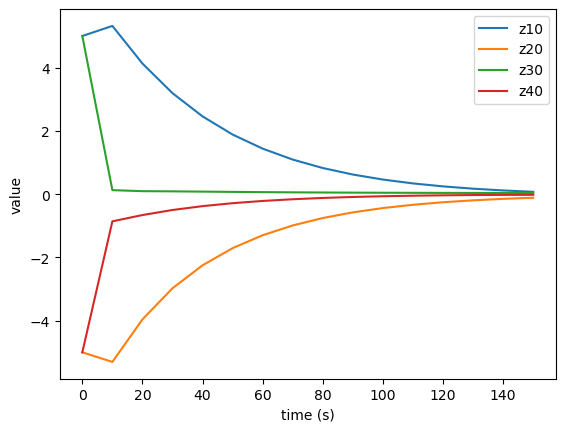

In [4]:
# Extract optimal state trajectories at the breakpoints (N+1 values, one per element boundary)
# m.iii = [0, 1, ..., N]; multiply by m.h.value to convert element indices to time in seconds.
idx = list(m.iii)
t = [k * m.h.value for k in idx]

z10 = [pyo.value(m.z10[i]) for i in idx]
z20 = [pyo.value(m.z20[i]) for i in idx]
z30 = [pyo.value(m.z30[i]) for i in idx]
z40 = [pyo.value(m.z40[i]) for i in idx]

# Plot optimal state trajectories (deviations from steady state, cm)
plt.plot(t, z10, label='z10')
plt.plot(t, z20, label='z20')
plt.plot(t, z30, label='z30')
plt.plot(t, z40, label='z40')

plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()

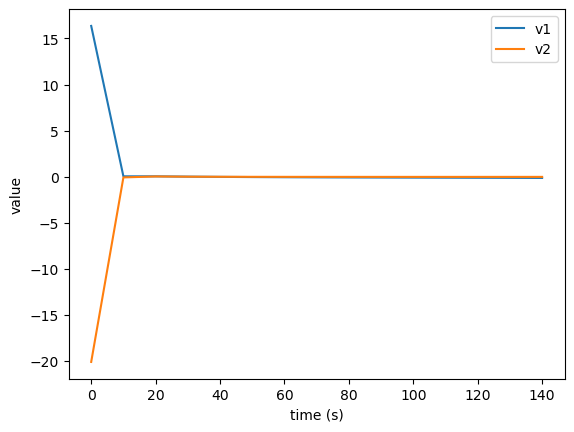

In [5]:
# Extract optimal control inputs (N values, one piecewise-constant value per finite element)
# m.i = [0, 1, ..., N-1]; multiply by m.h.value to convert element indices to time in seconds.
idx = list(m.i)
t = [k * m.h.value for k in idx]

v1 = [pyo.value(m.v1[i]) for i in idx]
v2 = [pyo.value(m.v2[i]) for i in idx]

# Plot optimal control trajectories (deviations from steady-state pump flows, ml/s)
plt.figure()  # new plot
plt.plot(t, v1, label='v1')
plt.plot(t, v2, label='v2')

plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()